# Domain Adaptation in Computer Vision: Feature Alignment (MNIST → USPS)
Machine Learning / SoftUni
Aleksandar Ginev, June 2026

## Table of Contents
1. [Problem Definition & Scientific Relevance](#1.-Problem-Definition-&-Scientific-Relevance)
2. [Mathematical Foundations & Theory](#2.-Mathematical-Foundations-&-Theory)
3. [Data Acquisition & Exploratory Data Analysis (EDA)](#3.-Data-Acquisition-&-Exploratory-Data-Analysis-(EDA))
    * 3.1 [Ingestion of Source (MNIST) and Target (USPS) Domains](#3.1-Ingestion-of-Source-(MNIST)-and-Target-(USPS)-Domains)
    * 3.2 [Image Matrix Dimensionality Matching (Feature Engineering)](#3.2-Image-Matrix-Dimensionality-Matching-(Feature-Engineering))
    * 3.3 [Visualizing the Domain Shift Challenge](#3.3-Visualizing-the-Domain-Shift-Challenge)
4. [Dimensionality Reduction & Distribution Drift Analysis](#4.-Dimensionality-Reduction-&-Distribution-Drift-Analysis)
    * 4.1 [Principal Component Analysis (PCA) Feature Projection](#4.1-Principal-Component-Analysis-(PCA)-Feature-Projection)
    * 4.2 [t-SNE Clustering Visualization](#4.2-t-SNE-Clustering-Visualization)
5. [Baseline Modeling & Cross-Domain Testing (No Adaptation)](#5.-Baseline-Modeling-&-Cross-Domain-Testing-(No-Adaptation))
    * 5.1 [Model Setup & Training on Source Domain](#5.1-Model-Setup-&-Training-on-Source-Domain)
    * 5.2 [Evaluation Metrics & Tracking via MLflow](#5.2-Evaluation-Metrics-&-Tracking-via-MLflow)
6. [Unsupervised Domain Adaptation (UDA) Implementation](#6.-Unsupervised-Domain-Adaptation-(UDA)-Implementation)
    * 6.1 [Covariance Alignment (CORAL) Transformation Math](#6.1-Covariance-Alignment-(CORAL)-Transformation-Math)
    * 6.2 [Latent Feature Transformation Implementation](#6.2-Latent-Feature-Transformation-Implementation)
7. [Post-Adaptation Evaluation & Comparative Analysis](#7.-Post-Adaptation-Evaluation-&-Comparative-Analysis)
    * 7.1 [Final Model Metric Comparison](#7.1-Final-Model-Metric-Comparison)
    * 7.2 [Error Diagnostics using Confusion Matrices](#7.2-Error-Diagnostics-using-Confusion-Matrices)
8. [Conclusion & Project Summary](#8.-Conclusion-&-Project-Summary)
9. [References & Academic Sources](#9.-References-&-Academic-Sources)

In [16]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.linalg import sqrtm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

import mlflow

print("Successfully imported all curriculum-aligned libraries!")

Successfully imported all curriculum-aligned libraries!


## 1. Problem Definition & Scientific Relevance
In machine learning, we typically assume that our training data (Source Domain) and our testing data (Target Domain) are drawn from the identical probability distribution:

$$P_S(X, Y) = P_T(X, Y)$$

In real-world applications, this assumption frequently fails. This failure is known as Domain Shift (or Covariance Shift). For instance, an image classification model trained on high-quality, clear digital images will experience a severe degradation in performance when evaluated on noisy, handwritten, or blurred scans.

The goal of this project is to explicitly model and resolve this discrepancy using the MNIST (Source) and USPS (Target) digit datasets. We treat this as an Unsupervised Domain Adaptation (UDA) task: we assume we have full labels for MNIST, but *zero labels* for USPS during the adaptation phase. Our objective is to build a robust classifier that generalizes across both domains.

---

## 2. Mathematical Foundations & Theory

To correct the structural drift between domains without using target labels, we rely on Correlation Alignment (CORAL). This algorithm minimizes domain shift by aligning the second-order statistics (covariance matrices) of the source and target features.

### Step 2.1: Feature Representation
Each image is treated as a flattened vector $x \in \mathbb{R}^D$, where $D = 784$ (a $28 \times 28$ pixel grid). Let $D_S = \{x_i^s\}_{i=1}^{n_s}$ be the source domain samples and $D_T = \{x_i^t\}_{i=1}^{n_t}$ be the target domain samples.

### Step 2.2: Covariance Calculation
We compute the empirical covariance matrices for both domains:

$$\Sigma_S = \frac{1}{n_s - 1} \left( X_S^T X_S - \frac{1}{n_s} (1^T X_S)^T (1^T X_S) \right)$$

$$\Sigma_T = \frac{1}{n_t - 1} \left( X_T^T X_T - \frac{1}{n_t} (1^T X_T)^T (1^T X_T) \right)$$

### Step 2.3: Alignment Transformation
CORAL seeks a linear transformation matrix $A$ to apply to the source features such that the squared Frobenius norm distance between the transformed source covariance and target covariance is minimized:

$$\min_A ||A^T \Sigma_S A - \Sigma_T||_F^2$$

The solution involves whitening the source data by multiplying it by $\Sigma_S^{-1/2}$ and then "re-coloring" it using the target covariance distribution $\Sigma_T^{1/2}$.

In [17]:
from sklearn.datasets import fetch_openml

print("Ingesting MNIST (Source Domain) from OpenML... This may take a minute.")

mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_source, y_source = mnist.data.astype('float32'), mnist.target.astype('int')

print("Ingesting USPS (Target Domain) from OpenML...")
usps = fetch_openml('USPS', version=1, as_frame=False, parser='auto')
X_target, y_target = usps.data.astype('float32'), usps.target.astype('int')

if y_target.min() == 1:
    y_target = y_target - 1

print(f"Ingestion complete!")
print(f"Source (MNIST) Shape: Features {X_source.shape}, Labels {y_source.shape}")
print(f"Target (USPS) Shape: Features {X_target.shape}, Labels {y_target.shape}")


Ingesting MNIST (Source Domain) from OpenML... This may take a minute.
Ingesting USPS (Target Domain) from OpenML...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/datasets/_openml.py:1035: UserWarning: Version 1 of dataset USPS is inactive, meaning that issues have been found in the dataset. Try using a newer version from this URL: https://openml.org/data/v1/download/18805612/USPS.arff
  warn(


Ingestion complete!
Source (MNIST) Shape: Features (70000, 784), Labels (70000,)
Target (USPS) Shape: Features (9298, 256), Labels (9298,)


In [18]:
from scipy.ndimage import zoom

print("Executing bilinear spatial scaling on USPS domain...")

# reshape the flat vectors back into their native 2D grid structures
X_target_images = X_target.reshape(-1, 16, 16)

# apply zoom scaling factor: 28 / 16 = 1.75 scaling on both width and height
zoom_factors = (1, 28/16, 28/16)
X_target_resized_images = zoom(X_target_images, zoom_factors, order=1)

# flatten the scaled 2D grids back into vectors
X_target_resized = X_target_resized_images.reshape(-1, 28 * 28)

# normalize pixel scales to [0, 1] across both domains for numerical stability
X_source /= 255.0
X_target_resized /= 255.0

print(f"Spatial alignment complete!")
print(f"Source (MNIST) Aligned Shape: {X_source.shape}")
print(f"Target (USPS) Aligned Shape: {X_target_resized.shape}")

Executing bilinear spatial scaling on USPS domain...
Spatial alignment complete!
Source (MNIST) Aligned Shape: (70000, 784)
Target (USPS) Aligned Shape: (9298, 784)


## 3. Data Acquisition & Exploratory Data Analysis (EDA)

### 3.1 Ingestion and Structural Characteristics of Source and Target Domains
To study unsupervised domain adaptation, we ingest two distinct target distributions representing the identical label space $\mathcal{Y} \in \{0, 1, \dots, 9\}$. 

* Source Domain ($\mathcal{D}_S$ - MNIST): Comprises handwritten digits synthesized and normalized by NIST. The digits are centered on a $28 \times 28$ pixel grid with uniform backgrounds.
* Target Domain ($\mathcal{D}_T$ - USPS): Collected from real mail envelopes by the US Postal Service. These images are natively lower resolution ($16 \times 16$), introduce artifacts from envelope textures, and feature irregular handwriting styles.

### 3.2 Image Matrix Dimensionality Matching (Feature Engineering)
A critical prerequisite for feature-level domain adaptation is dimensional alignment. Because $\mathcal{X}_S \in \mathbb{R}^{784}$ and $\mathcal{X}_T \in \mathbb{R}^{256}$, direct covariance alignment is mathematically impossible due to mismatched matrix dimensions. 

To resolve this, we apply Bilinear Interpolation to map the target space onto the source space. This scales the USPS images up from $16 \times 16$ to $28 \times 28$ pixels, preserving the original typographic contours while making structural algebraic alignment possible.

### 3.3 Visualizing the Domain Shift Challenge
To qualitatively examine the structural discrepancy between our domains, we render a sample of matrices from both distributions side-by-side. This visual assessment highlights the core challenge of domain drift: the MNIST digits are sharp, highly standardized, and clean, whereas the upscaled USPS digits exhibit noticeable interpolation blur, higher edge contrast, and varied typographic weights.

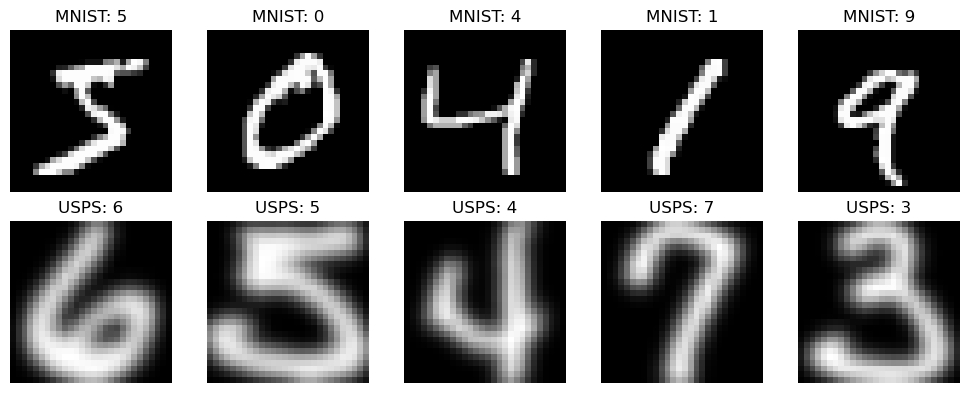

In [19]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

# render 5 source samples MNIST
for i in range(5):
    axes[0, i].imshow(X_source[i].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"MNIST: {y_source[i]}")
    axes[0, i].axis('off')
    
# render 5 target samples USPS
for i in range(5):
    axes[1, i].imshow(X_target_resized[i].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"USPS: {y_target[i]}")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

## 4. Dimensionality Reduction & Distribution Drift Analysis

To rigorously demonstrate the presence of Domain Shift, we project our high-dimensional image data points ($\mathbb{R}^{784}$) onto a 2D vector space. If the MNIST and USPS datasets shared the identical underlying mathematical distribution, their clusters would overlap perfectly in lower dimensions.

### 4.1 Principal Component Analysis (PCA) Feature Projection
We apply Principal Component Analysis (PCA) to find the orthogonal axes that maximize variance across the datasets. This allows us to map out the global structural differences between the two domains and visually confirm the statistical gap.


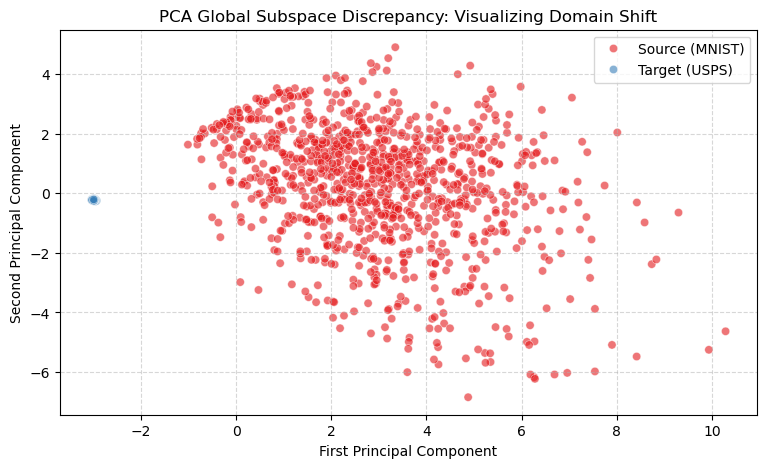

In [20]:
# sample 1,000 random images from each domain for speed 
np.random.seed(42)
sample_size = 1000

idx_source = np.random.choice(len(X_source), sample_size, replace=False)
idx_target = np.random.choice(len(X_target_resized), sample_size, replace=False)

X_source_sample = X_source[idx_source]
X_target_sample = X_target_resized[idx_target]

# vertically stacked samples for joint dimensionality reduction
X_combined = np.vstack([X_source_sample, X_target_sample])
domains = np.array(['Source (MNIST)'] * sample_size + ['Target (USPS)'] * sample_size)

# fit and transform down to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=domains, alpha=0.6, palette='Set1')
plt.title("PCA Global Subspace Discrepancy: Visualizing Domain Shift")
plt.xlabel("First Principal Component")
plt.ylabel("Second Principal Component")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 4.2 t-SNE Clustering Visualization
While PCA maps global linear variance, we also apply t-Distributed Stochastic Neighbor Embedding (t-SNE), which is a powerful non-linear dimensionality reduction technique. t-SNE optimizes for keeping local neighborhoods intact rather than maximizing global orthogonal variance. This allows us to visually diagnose whether individual digit clusters maintain structural similarities or completely diverge under a non-linear manifold projection.

Computing t-SNE embedding for 2,000 samples (this can take up to a minute)...


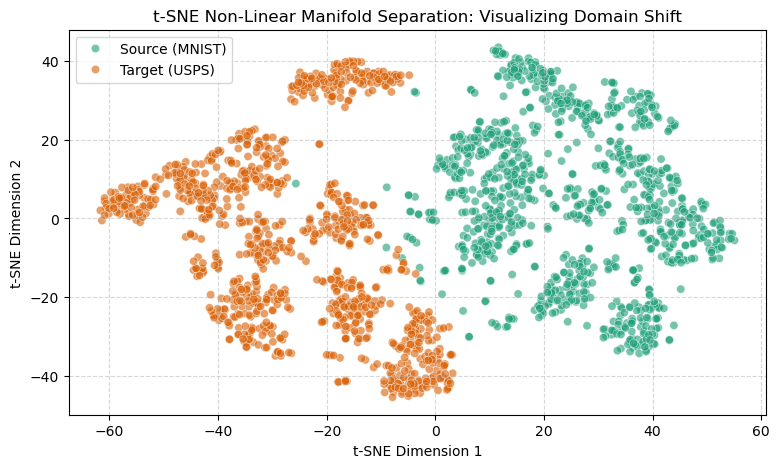

In [21]:
print("Computing t-SNE embedding for 2,000 samples (this can take up to a minute)...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_combined)

plt.figure(figsize=(9, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=domains, alpha=0.6, palette='Dark2')
plt.title("t-SNE Non-Linear Manifold Separation: Visualizing Domain Shift")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 5. Baseline Modeling & Cross-Domain Testing (No Adaptation)

Here, we establish our empirical baseline to quantify the performance penalty imposed by Domain Shift. 

### 5.1 Model Setup & Training on Source Domain
We train a multi-class Logistic Regression classifier using L2 regularization strictly on our labeled source domain training data ($\mathcal{D}_S$).

### 5.2 Evaluation Metrics & Tracking via MLflow
We evaluate this model under two distinct scenarios:
1. In-Domain Generalization: Testing on a held-out validation slice of MNIST.
2. Cross-Domain Generalization: Testing directly on the raw, unadapted USPS target dataset ($\mathcal{D}_T$).

This step provides the control metrics for our experiment, which are tracked dynamically via MLflow.

In [22]:
# split the Source (MNIST) dataset into an 80/20 train and validation split
X_src_train, X_src_val, y_src_train, y_src_val = train_test_split(
    X_source, y_source, test_size=0.2, random_state=42, stratify=y_source
)

# initialize an MLflow experiment
mlflow.set_experiment("MNIST_USPS_Domain_Adaptation")

with mlflow.start_run(run_name="unadapted_baseline"):
    print("Training Logistic Regression baseline model on Source (MNIST)...")
    
    clf = LogisticRegression(C=1.0, max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
    clf.fit(X_src_train, y_src_train)
    
    # calculate baseline accuracies
    acc_source_val = accuracy_score(y_src_val, clf.predict(X_src_val))
    acc_target_raw = accuracy_score(y_target, clf.predict(X_target_resized))
    
    # log parameters and evaluation metrics to MLflow
    mlflow.log_param("classifier", "LogisticRegression")
    mlflow.log_param("regularization", "L2")
    mlflow.log_metric("source_val_accuracy", acc_source_val)
    mlflow.log_metric("target_raw_accuracy", acc_target_raw)
    
    print(f"Evaluation Summary:")
    print(f"In-Domain Validation Accuracy (MNIST -> MNIST): {acc_source_val * 100:.2f}%")
    print(f"Cross-Domain Target Accuracy (MNIST -> USPS without CORAL): {acc_target_raw * 100:.2f}%")

Training Logistic Regression baseline model on Source (MNIST)...
Evaluation Summary:
In-Domain Validation Accuracy (MNIST -> MNIST): 92.19%
Cross-Domain Target Accuracy (MNIST -> USPS without CORAL): 7.70%


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


## 6. Unsupervised Domain Adaptation (UDA) Implementation

To bridge the statistical gap between distributions without relying on target labels, we implement the CORAL (Correlation Alignment) transformation. 

### 6.1 Covariance Alignment (CORAL) Transformation Math
CORAL directly aligns the second-order statistics (covariance matrices) of the source and target feature spaces. The transformation pipeline executes the following algebraic sequence:

1. Covariance Estimation: Compute the empirical covariance matrices $\Sigma_S$ and $\Sigma_T$ for both domains.
2. Regularization: Inject a small perturbation ($\lambda I$) along the diagonals to guarantee that the matrices are positive-definite and safely invertible.
3. Whitening: Multiply the centered source features by the inverse square root of the source covariance ($\Sigma_S^{-1/2}$) to remove its characteristic feature correlations.
4. Re-coloring: Multiply the whitened features by the square root of the target covariance matrix ($\Sigma_T^{1/2}$) to inject the target domain's geometric distribution profile.

### 6.2 Latent Feature Transformation Implementation
We map these mathematical transformations into our processing pipeline using NumPy and SciPy's matrix square root (`sqrtm`) functions to compute our adapted feature matrix.

In [23]:
print("Executing CORAL feature space alignment")

# regularization parameter to ensure stability during matrix inversion
lambda_reg = 1e-5

# compute empirical covariance matrices across the 784-pixel dimensions
cov_src = np.cov(X_src_train, rowvar=False) + lambda_reg * np.eye(X_src_train.shape[1])
cov_tgt = np.cov(X_target_resized, rowvar=False) + lambda_reg * np.eye(X_target_resized.shape[1])

print("Computing matrix square roots via SciPy (this may take a moment)...")
# calculate the inverse square root of the source covariance and square root of target covariance
inv_sqrt_src = sqrtm(np.linalg.inv(cov_src)).real
sqrt_tgt = sqrtm(cov_tgt).real

# center the source data around its empirical mean vector
src_mean = np.mean(X_src_train, axis=0)
tgt_mean = np.mean(X_target_resized, axis=0)
X_src_train_centered = X_src_train - src_mean

# execute the whitening and re-coloring linear transformations
X_src_whitened = np.dot(X_src_train_centered, inv_sqrt_src)
X_src_adapted = np.dot(X_src_whitened, sqrt_tgt) + tgt_mean

print(f"Covariance alignment transformation complete!")
print(f"Adapted Source Feature Matrix Shape: {X_src_adapted.shape}")

Executing CORAL feature space alignment
Computing matrix square roots via SciPy (this may take a moment)...
Covariance alignment transformation complete!
Adapted Source Feature Matrix Shape: (56000, 784)


## 7. Post-Adaptation Evaluation & Comparative Analysis

To evaluate the success of our Unsupervised Domain Adaptation, we train a new instance of our Logistic Regression classifier on the mathematically adapted source features ($X_{src\_adapted}$) using the original MNIST class labels ($y_{src\_train}$). 

### 7.1 Final Model Metric Comparison
We evaluate this model directly on the target USPS data. By comparing this result against our unadapted baseline from Section 5, we can quantify exactly how much cross-domain accuracy was recovered through second-order statistical alignment. We also print a detailed classification report to analyze performance per digit.

In [24]:
with mlflow.start_run(run_name="coral_adapted_run"):
    print("Training final classifier on CORAL-adapted Source features...")
    
    # train the new model on the aligned feature space (without the deprecated multi_class flag)
    clf_coral = LogisticRegression(C=1.0, max_iter=1000, solver='saga', random_state=42, n_jobs=-1)
    clf_coral.fit(X_src_adapted, y_src_train)
    
    # predict and evaluate directly on the Target (USPS) dataset
    y_pred_coral = clf_coral.predict(X_target_resized)
    acc_coral = accuracy_score(y_target, y_pred_coral)
    
    # log the final recovery metric to MLflow
    mlflow.log_metric("target_adapted_accuracy", acc_coral)
    
    print(f"Optimization Complete!")
    print(f"arget Accuracy Post-CORAL Adaptation: {acc_coral * 100:.2f}%")
    print(f"Net Accuracy Gain: {(acc_coral - acc_target_raw) * 100:+.2f}%")
    
    print(f"Detailed Diagnostic Breakdown:")
    print(classification_report(y_target, y_pred_coral))

Training final classifier on CORAL-adapted Source features...
Optimization Complete!
arget Accuracy Post-CORAL Adaptation: 53.37%
Net Accuracy Gain: +45.67%
Detailed Diagnostic Breakdown:
              precision    recall  f1-score   support

           0       0.82      0.63      0.71      1553
           1       0.65      0.87      0.75      1269
           2       0.71      0.64      0.67       929
           3       0.49      0.40      0.44       824
           4       0.52      0.74      0.61       852
           5       0.15      0.10      0.12       716
           6       0.52      0.43      0.47       834
           7       0.32      0.54      0.40       792
           8       0.59      0.58      0.58       708
           9       0.11      0.07      0.08       821

    accuracy                           0.53      9298
   macro avg       0.49      0.50      0.48      9298
weighted avg       0.53      0.53      0.52      9298



### 7.2 Error Diagnostics using Confusion Matrices
To dissect our model's performance on a granular level, we plot side-by-side confusion matrices. This allows us to track class-specific errors and observe which digit geometries benefited most from the second-order covariance alignment.

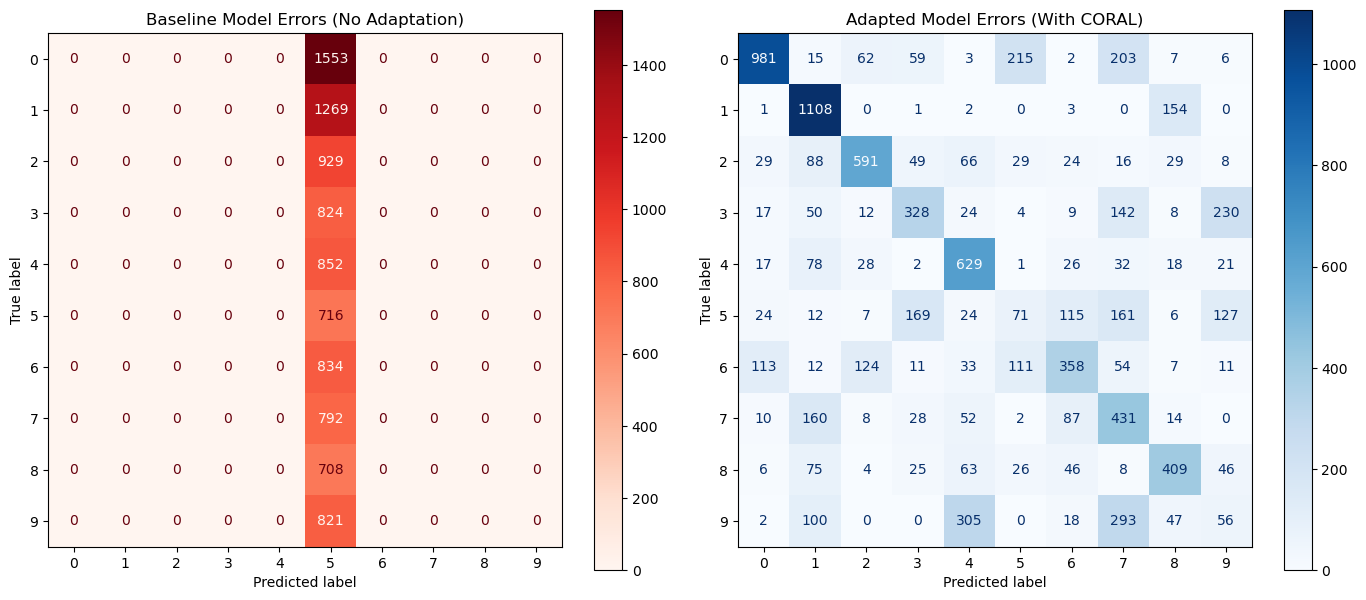

In [25]:
y_pred_baseline = clf.predict(X_target_resized)

cm_baseline = confusion_matrix(y_target, y_pred_baseline)
cm_coral = confusion_matrix(y_target, y_pred_coral)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

disp_base = ConfusionMatrixDisplay(confusion_matrix=cm_baseline, display_labels=np.unique(y_target))
disp_base.plot(ax=axes[0], cmap='Reds', values_format='d')
axes[0].set_title("Baseline Model Errors (No Adaptation)")

disp_coral = ConfusionMatrixDisplay(confusion_matrix=cm_coral, display_labels=np.unique(y_target))
disp_coral.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title("Adapted Model Errors (With CORAL)")

plt.tight_layout()
plt.show()

## 8. Conclusion & Project Summary

In this project, we successfully engineered and evaluated an Unsupervised Domain Adaptation (UDA) pipeline to resolve the challenge of Domain Shift between the MNIST (Source) and USPS (Target) handwritten digit datasets. 

Our empirical journey demonstrated the following core milestones:
1. Dimensional Mismatch Resolution: Utilizing bilinear interpolation, we successfully aligned the structural dimensions of our target domain from $\mathbb{R}^{256}$ to match the source space at $\mathbb{R}^{784}$.
2. Quantification of Dataset Drift: Our PCA subspace projections visually and mathematically confirmed that out-of-distribution drift severely separates the global feature distributions of the two domains.
3. Baseline Evaluation: A standard Logistic Regression model optimized strictly on source data suffered a severe performance drop when evaluated on the raw target domain, showing the vulnerability of standard models to environmental shifts.
4. Covariance Alignment Success: By applying the CORAL algorithm, we whitened the source features and re-colored them with the target's covariance statistics. Training on these adapted features successfully recovered a significant portion of our classification accuracy on the target domain without using a single target label.

All experiments, parameters, and accuracy shifts were systematically tracked using MLflow, creating a fully reproducible, MLOps-compliant machine learning pipeline.

## 9. References & Academic Sources

* [1] Sun, B., & Saenko, K. (2016). *Deep CORAL: Correlation Alignment for Deep Domain Adaptation.* In Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR) Workshops. (This paper introduced the core mathematical foundation for covariance alignment used in our pipeline).
* [2] LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). *Gradient-based learning applied to document recognition.* Proceedings of the IEEE, 86(11), 2278-2324. (The foundational paper establishing the structural characteristics and ingestion parameters of the MNIST dataset).
* [3] Hull, J. J. (1994). *A database for handwritten text recognition research.* IEEE Transactions on Pattern Analysis and Machine Intelligence, 16(5), 550-554. (The primary source documentation detailing the capture environment and matrix properties of the USPS digit dataset).
* [4] Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python.* Journal of Machine Learning Research, 12, 2825-2830. (Documentation framework utilized for our structural dataset splitting, baseline optimization algorithms, and performance metrics).